# Portfolio Analysis

Compare independent signal backtests with fractional-Kelly portfolio simulation.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from backtesting import BacktestConfig, Backtester, PortfolioBacktester
from backtesting.portfolio_backtester import portfolio_config_from_backtest_config
from scripts.backtest import demo_signals

In [2]:
signals = demo_signals()
base_config = BacktestConfig(save_results=False, edge_threshold=0.02)
independent = Backtester(base_config).run(signals)
portfolio_config = portfolio_config_from_backtest_config(
    base_config, kelly_fraction=0.4, max_exposure=0.2
)
portfolio = PortfolioBacktester(portfolio_config).run(signals)
independent.report.metrics, portfolio.report.metrics

2026-05-15 14:31:07 [info     ] backtest_completed             bets=45 grade=Fail run_id=8dd616a7-c94c-40ad-b607-690ac14198e4 strategy=gbdt_v1
2026-05-15 14:31:07 [info     ] portfolio_backtest_completed   grade=Fail run_id=19ec6e4c-80ed-4e1e-9c83-06a24906eb87 trades=80


({'bet_count': 45.0,
  'mean_edge': 0.01666666666666667,
  'brier_score': 0.22429722222222223,
  'log_loss': 0.6413782771102439,
  'spearman_edge_outcome': 0.6358618050338198,
  'kendall_edge_outcome': 0.5865213311157377,
  'net_pnl': 1927.9005643204348,
  'total_stake': 4500.0,
  'return_on_allocated_capital': 0.4284223476267633,
  'sharpe': 3.116556268848392,
  'sortino': 8439.05252966596,
  'profit_factor': 2.482601272211662,
  'max_drawdown': -300.07,
  'calmar': 6.424836085981387,
  'hit_rate_edge_ge_1%': 0.7111111111111111,
  'hit_rate_edge_ge_2%': 0.7111111111111111,
  'hit_rate_edge_ge_4%': 1.0,
  'hit_rate_edge_ge_8%': 0.0},
 {'bet_count': 80.0,
  'mean_edge': 0.016375000000000004,
  'brier_score': 0.226613125,
  'log_loss': 0.646173031787073,
  'spearman_edge_outcome': 0.6574732758969527,
  'kendall_edge_outcome': 0.6071374769210403,
  'net_pnl': 3522.0972319714238,
  'total_stake': 9623.829185820414,
  'return_on_allocated_capital': 0.3659766984601952,
  'sharpe': 3.32796938

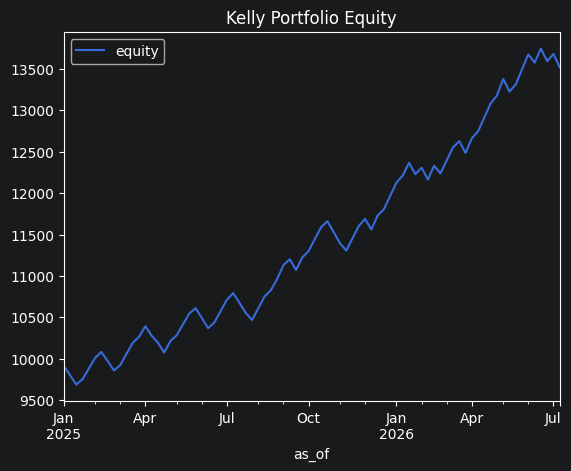

In [3]:
equity = portfolio.equity_frame()
equity.plot(x="as_of", y="equity", title="Kelly Portfolio Equity")
plt.show()

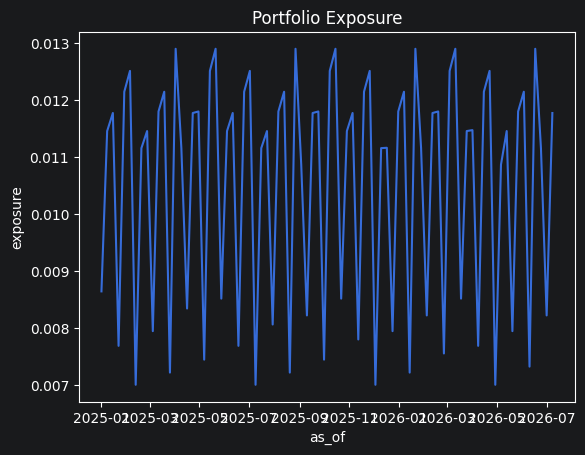

In [4]:
sns.lineplot(data=equity, x="as_of", y="exposure")
plt.title("Portfolio Exposure")
plt.show()